# 🎲 Bernoulli Dağılımı (Bernoulli Distribution)
### Olasılık Dağılımları Serisi - 01

---

## 📌 1. Giriş ve Sezgisel Açıklama

**Bernoulli Dağılımı**, olasılık teorisi ve istatistiğin en temel ve en yalın **ayrık (discrete) olasılık dağılımıdır**.

Bir rastgele deneyin **yalnızca iki olası sonucu** varsa (örneğin: *Başarılı / Başarısız*, *Yazı / Tura*, *Evet / Hayır*, *1 / 0*), bu deneye **Bernoulli Deneyi (Bernoulli Trial)**, bu deneyin sonucunu modelleyen rastgele değişkene ise **Bernoulli Rastgele Değişkeni** denir.

> 💡 **Tarihsel Not:** Bu dağılım, İsviçreli ünlü matematikçi **Jacob Bernoulli (1655–1705)** tarafından ortaya konmuş ve 1713 yılında yayımlanan *"Ars Conjectandi"* adlı başyapıtında detaylandırılmıştır.

### 🌍 Günlük Hayattan Örnekler:
1. **Madeni Para Atışı:** Yazı ($1$) veya Tura ($0$).
2. **E-posta Filtreleme:** Bir e-postanın Spam ($1$) veya Güvenli ($0$) olması.
3. **Dijital Pazarlama (CTR):** Web sitesindeki reklama tıklanması ($1$) veya tıklanmaması ($0$).
4. **Kalite Kontrol:** Üretim bandından çıkan bir ürünün Kusurlu ($1$) veya Kusursuz ($0$) olması.
5. **Tıp / Tanı:** Bir test sonucunun Pozitif ($1$) veya Negatif ($0$) çıkması.

---
## 📐 2. Matematiksel Tanım ve Formüller

Bir rastgele değişken $X$, $p$ başarı parametresi ile Bernoulli dağılımına sahipse şu şekilde gösterilir:

$$X \sim \text{Bernoulli}(p)$$

Burada:
- $p \in [0, 1]$: Başarı olasılığıdır ($P(X = 1) = p$)
- $q = 1 - p$: Başarısızlık olasılığıdır ($P(X = 0) = 1 - p$)
- Olay uzayı: $k \in \{0, 1\}$

### 🔹 Olasılık Kütle Fonksiyonu (Probability Mass Function - PMF)
Olasılık kütle fonksiyonu, $X$ değişkeninin belirli bir $k$ değerini alma olasılığını verir:

$$P(X = k) = p^k (1 - p)^{1 - k}, \quad k \in \{0, 1\}$$

- $k = 1$ için: $P(X = 1) = p^1 (1 - p)^0 = p$
- $k = 0$ için: $P(X = 0) = p^0 (1 - p)^1 = 1 - p$

### 🔹 Kümülatif Dağılım Fonksiyonu (Cumulative Distribution Function - CDF)
Kümülatif dağılım fonksiyonu $F(k) = P(X \le k)$:

$$F(k) = \begin{cases} 
0, & k < 0 \\
1 - p, & 0 \le k < 1 \\
1, & k \ge 1
\end{cases}$$

---

## 📊 3. İstatistiksel Özellikler ve Momentler

| İstatistiksel Metrik | Formül | Açıklama |
| :--- | :--- | :--- |
| **Beklenen Değer (Mean / $E[X]$)** | $\mu = p$ | Dağılımın merkez noktasıdır. Ortalama başarı oranıdır. |
| **Varyans (Variance / $\text{Var}(X)$)** | $\sigma^2 = p(1 - p)$ | Dağılımın yayılımıdır. $p = 0.5$ olduğunda maksimum değerine ($0.25$) ulaşır. |
| **Standart Sapma (Standard Deviation)** | $\sigma = \sqrt{p(1 - p)}$ | Varyansın kareköküdür. |
| **Çarpıklık (Skewness / $\gamma_1$)** | $\gamma_1 = \frac{1 - 2p}{\sqrt{p(1 - p)}}$ | $p = 0.5$ ise $\gamma_1 = 0$ (simetrik). $p < 0.5$ ise sağa çarpık, $p > 0.5$ ise sola çarpıktır. |
| **Basıklık (Kurtosis / $\text{Kurt}(X)$)** | $\text{Kurt} = \frac{1 - 6p(1-p)}{p(1-p)}$ | Dağılımın kuyruk kalınlığını ifade eder. |
| **Mod (Mode)** | $\begin{cases} 0, & p < 0.5 \\ 1, & p > 0.5 \\ \{0, 1\}, & p = 0.5 \end{cases}$ | En yüksek olasılığa sahip değerdir. |
| **Medyan (Median)** | $\begin{cases} 0, & p < 0.5 \\ 1, & p > 0.5 \\ [0, 1], & p = 0.5 \end{cases}$ | Dağılımı iki eşit parçaya bölen değerdir. |

---
## 💻 4. Python ile Kütüphaneleri Dahil Etme ve Ortam Hazırlığı

In [1]:
# Gerekli kütüphanelerin import edilmesi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import bernoulli

# Grafik estetiği ve Türkçe karakter desteği için ayarlar
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Tekrarlanabilirlik için rastgelelik tohumu (seed)
np.random.seed(42)

print("✅ Kütüphaneler başarıyla yüklendi!")

✅ Kütüphaneler başarıyla yüklendi!


---
## 🧪 5. NumPy ile Bernoulli Dağılımı Simülasyonu

NumPy kütüphanesinde doğrudan `bernoulli` fonksiyonu olmasa da, $n=1$ deneme sayılı **Binom Dağılımı** (`np.random.binomial(n=1, p=p, size=N)`), matematiksel olarak **Bernoulli Dağılımı**'na tam olarak eşittir.

In [2]:
# Parametreler
p = 0.35          # Başarı olasılığı (Örn: Tıklama oranı %35)
n_samples = 10000 # Örneklem boyutu

# 1. Yöntem: Binom dağılımı ile (n=1)
samples_binomial = np.random.binomial(n=1, p=p, size=n_samples)

# 2. Yöntem: np.random.choice ile
samples_choice = np.random.choice([0, 1], p=[1-p, p], size=n_samples)

# İstatistiksel Değerlerin Hesaplanması
sample_mean = np.mean(samples_binomial)
sample_var = np.var(samples_binomial)
sample_std = np.std(samples_binomial)

# Teorik Değerler
theoretical_mean = p
theoretical_var = p * (1 - p)
theoretical_std = np.sqrt(p * (1 - p))

# Sonuçları Karşılaştırmalı Tablo Olarak Gösterelim
comparison_df = pd.DataFrame({
    "Metrik": ["Beklenen Değer (Mean)", "Varyans (Variance)", "Standart Sapma (Std Dev)", "Başarı Sayısı (k=1)", "Başarısızlık Sayısı (k=0)"],
    "Teorik Değer": [f"{theoretical_mean:.4f}", f"{theoretical_var:.4f}", f"{theoretical_std:.4f}", f"{int(n_samples * p)}", f"{int(n_samples * (1-p))}"],
    "Örneklem Değeri": [f"{sample_mean:.4f}", f"{sample_var:.4f}", f"{sample_std:.4f}", f"{np.sum(samples_binomial == 1)}", f"{np.sum(samples_binomial == 0)}"]
})

display(comparison_df)

,Metrik,Teorik Değer,Örneklem Değeri
0,Beklenen Değer (Mean),0.3500,0.3397
1,Varyans (Variance),0.2275,0.2243
2,Standart Sapma (Std Dev),0.4770,0.4736
3,Başarı Sayısı (k=1),3500,3397
4,Başarısızlık Sayısı (k=0),6500,6603


---
## 🔬 6. SciPy ile Bernoulli Fonksiyonları (PMF, CDF, PPF, Stats)

`scipy.stats.bernoulli` modülü, Bernoulli dağılımına ait teorik olasılık fonksiyonlarını doğrudan hesaplamamızı sağlar.

In [3]:
p = 0.6  # Başarı olasılığı %60

# 1. PMF (Olasılık Kütle Fonksiyonu) - P(X = k)
pmf_0 = bernoulli.pmf(k=0, p=p)
pmf_1 = bernoulli.pmf(k=1, p=p)

# 2. CDF (Kümülatif Dağılım Fonksiyonu) - P(X <= k)
cdf_0 = bernoulli.cdf(k=0, p=p)
cdf_1 = bernoulli.cdf(k=1, p=p)

# 3. PPF (Percent Point Function / Quantile / Ters CDF)
ppf_25 = bernoulli.ppf(q=0.25, p=p) # %25'lik dilim
ppf_75 = bernoulli.ppf(q=0.75, p=p) # %75'lik dilim

# 4. Stats ile Momentlerin Hesaplanması (m=mean, v=var, s=skew, k=kurt)
mean, var, skew, kurt = bernoulli.stats(p=p, moments='mvsk')

print(f"🔹 [p = {p}] İçin SciPy Hesaplamaları:")
print("-" * 45)
print(f"PMF: P(X = 0) = {pmf_0:.2f} (Başarısızlık), P(X = 1) = {pmf_1:.2f} (Başarı)")
print(f"CDF: F(0) = P(X <= 0) = {cdf_0:.2f}, F(1) = P(X <= 1) = {cdf_1:.2f}")
print(f"Momentler -> Ortalama: {mean:.2f} | Varyans: {var:.2f} | Çarpıklık: {skew:.4f} | Basıklık: {kurt:.4f}")

🔹 [p = 0.6] İçin SciPy Hesaplamaları:
---------------------------------------------
PMF: P(X = 0) = 0.40 (Başarısızlık), P(X = 1) = 0.60 (Başarı)
CDF: F(0) = P(X <= 0) = 0.40, F(1) = P(X <= 1) = 1.00
Momentler -> Ortalama: 0.60 | Varyans: 0.24 | Çarpıklık: -0.4082 | Basıklık: -1.8333


---
## 📈 7. Kapsamlı Görselleştirmeler

### 🎨 Grafik 1: Farklı $p$ Parametreleri için PMF (Olasılık Kütle Fonksiyonu)

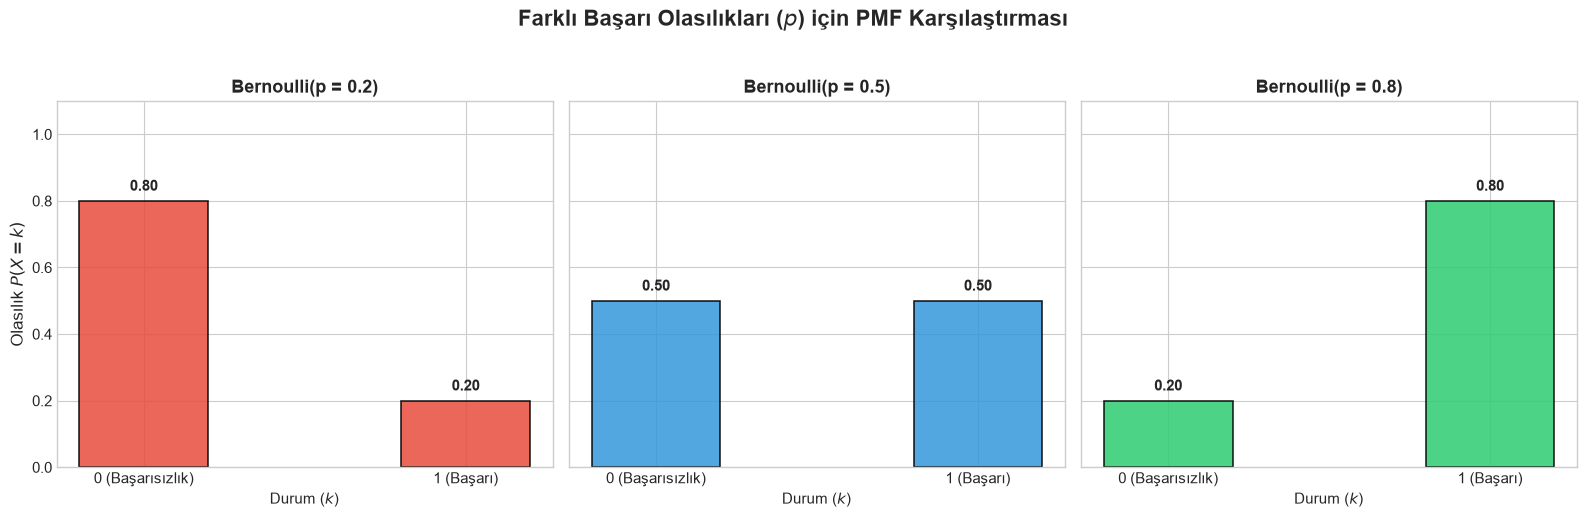

In [4]:
p_values = [0.2, 0.5, 0.8]
x_vals = [0, 1]
colors = ['#e74c3c', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for idx, (p_val, color) in enumerate(zip(p_values, colors)):
    pmf_vals = [bernoulli.pmf(x, p=p_val) for x in x_vals]
    bars = axes[idx].bar(x_vals, pmf_vals, color=color, alpha=0.85, width=0.4, edgecolor='black', linewidth=1.2)
    
    # Çubukların üzerine değerleri yazdıralım
    for bar in bars:
        height = bar.get_height()
        axes[idx].annotate(f'{height:.2f}',
                           xy=(bar.get_x() + bar.get_width() / 2, height),
                           xytext=(0, 5), textcoords="offset points",
                           ha='center', va='bottom', fontweight='bold')
    
    axes[idx].set_title(f'Bernoulli(p = {p_val})', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Durum ($k$)', fontsize=11)
    axes[idx].set_xticks([0, 1])
    axes[idx].set_xticklabels(['0 (Başarısızlık)', '1 (Başarı)'])
    axes[idx].set_ylim(0, 1.1)

axes[0].set_ylabel('Olasılık $P(X = k)$', fontsize=12)
plt.suptitle('Farklı Başarı Olasılıkları ($p$) için PMF Karşılaştırması', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 🎨 Grafik 2: Kümülatif Dağılım Fonksiyonu (CDF) - Basamak Grafiği

<>:15: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:15: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/63/dblmft916gb17xgfh55xpb980000gn/T/ipykernel_95673/1039273515.py:15: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.ylabel('Kümülatif Olasılık $F(x) = P(X \leq x)$', fontsize=12)


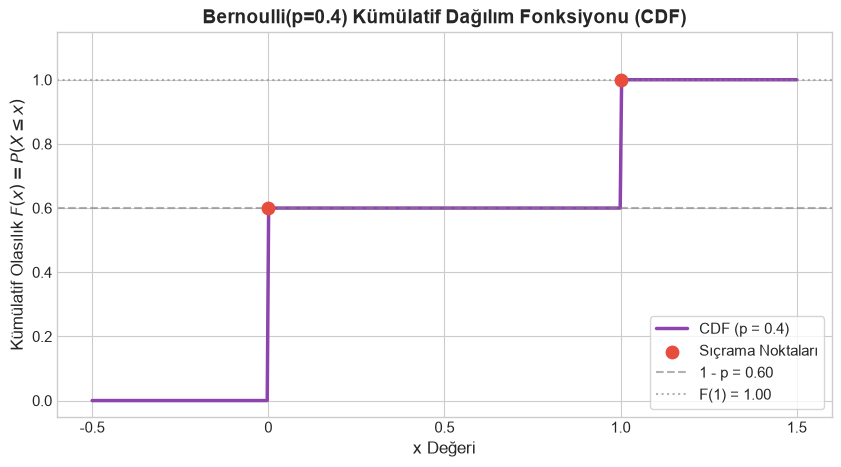

In [5]:
p = 0.4
x_extended = np.linspace(-0.5, 1.5, 500)
cdf_extended = [bernoulli.cdf(val, p=p) for val in x_extended]

plt.figure(figsize=(10, 5))
plt.plot(x_extended, cdf_extended, color='#8e44ad', linewidth=2.5, label=f'CDF (p = {p})')

# Kritik noktaları işaretleyelim
plt.scatter([0, 1], [1 - p, 1], color='#e74c3c', s=80, zorder=5, label='Sıçrama Noktaları')
plt.axhline(1 - p, color='gray', linestyle='--', alpha=0.6, label=f'1 - p = {1-p:.2f}')
plt.axhline(1.0, color='gray', linestyle=':', alpha=0.6, label='F(1) = 1.00')

plt.title(f'Bernoulli(p={p}) Kümülatif Dağılım Fonksiyonu (CDF)', fontsize=14, fontweight='bold')
plt.xlabel('x Değeri', fontsize=12)
plt.ylabel('Kümülatif Olasılık $F(x) = P(X \leq x)$', fontsize=12)
plt.xticks([-0.5, 0, 0.5, 1.0, 1.5], ['-0.5', '0', '0.5', '1.0', '1.5'])
plt.ylim(-0.05, 1.15)
plt.legend(loc='lower right', frameon=True)
plt.show()

### 🎨 Grafik 3: Varyansın $p$ Parametresine Göre Değişimi

Bernoulli dağılımında varyans formülü $\text{Var}(X) = p(1 - p)$ şeklindedir.
- $p = 0$ veya $p = 1$ iken belirsizlik yoktur, varyans $0$'dır.
- $p = 0.5$ olduğunda belirsizlik (entropi) en üst düzeydedir ve varyans **maksimum değeri olan $0.25$'e** ulaşır.

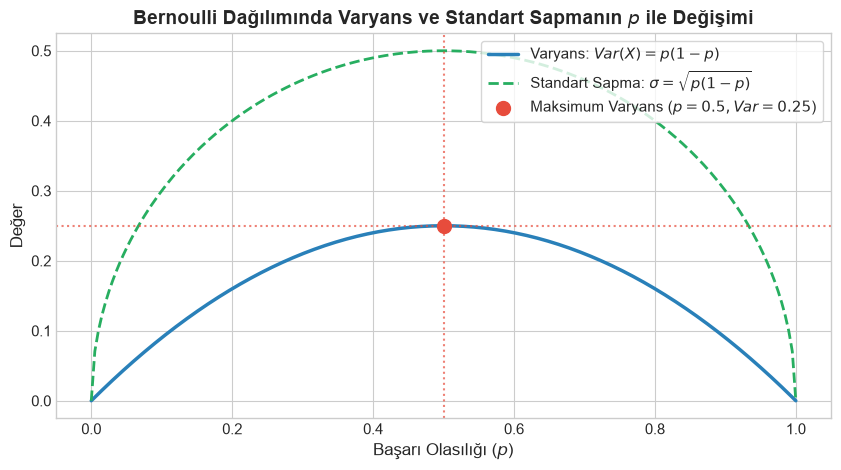

In [6]:
p_range = np.linspace(0, 1, 200)
variance_range = p_range * (1 - p_range)
std_range = np.sqrt(variance_range)

plt.figure(figsize=(10, 5))
plt.plot(p_range, variance_range, color='#2980b9', linewidth=2.5, label=r'Varyans: $Var(X) = p(1-p)$')
plt.plot(p_range, std_range, color='#27ae60', linewidth=2, linestyle='--', label=r'Standart Sapma: $\sigma = \sqrt{p(1-p)}$')

# Maksimum varyans noktası (p=0.5)
plt.scatter(0.5, 0.25, color='#e74c3c', s=100, zorder=5, label='Maksimum Varyans ($p=0.5, Var=0.25$)')
plt.axvline(0.5, color='#e74c3c', linestyle=':', alpha=0.7)
plt.axhline(0.25, color='#e74c3c', linestyle=':', alpha=0.7)

plt.title('Bernoulli Dağılımında Varyans ve Standart Sapmanın $p$ ile Değişimi', fontsize=14, fontweight='bold')
plt.xlabel('Başarı Olasılığı ($p$)', fontsize=12)
plt.ylabel('Değer', fontsize=12)
plt.legend(loc='upper right', frameon=True)
plt.show()

### 🎨 Grafik 4: Büyük Sayılar Yasası (Law of Large Numbers) Simülasyonu

**Büyük Sayılar Yasası'na göre;** Deneme sayısı ($N$) arttıkça, örneklem ortalaması teorik beklenen değer olan $p$'ye yakınsar ($\lim_{N \to \infty} \bar{X}_N = p$).

In [7]:
p_true = 0.65
n_trials = 5000

# Rastgele Bernoulli denemeleri üretelim
trials = np.random.binomial(n=1, p=p_true, size=n_trials)

# Kümülatif ortalama (Cumulative Mean)
cumulative_means = np.cumsum(trials) / np.arange(1, n_trials + 1)

plt.figure(figsize=(12, 6))
plt.plot(range(1, n_trials + 1), cumulative_means, color='#16a085', linewidth=1.5, label='Örneklem Kümülatif Ortalaması ($\bar{X}_N$)')
plt.axhline(p_true, color='#c0392b', linestyle='--', linewidth=2, label=f'Teorik Başarı Oranı (p = {p_true})')

plt.title('Büyük Sayılar Yasası: Deneme Sayısı Arttıkça $p$\'ye Yakınsama', fontsize=14, fontweight='bold')
plt.xlabel('Deneme Sayısı ($N$)', fontsize=12)
plt.ylabel('Kümülatif Ortalama', fontsize=12)
plt.ylim(0.4, 0.9)
plt.legend(loc='lower right', frameon=True)
plt.show()

ValueError: 
Örneklem Kümülatif Ortalaması ($ar{X}_N$)
                               ^
ParseException: Expected end of text, found '$'  (at char 31), (line:1, col:32)

<Figure size 1200x600 with 1 Axes>

---
## 💼 8. Gerçek Hayat Uygulama Senaryoları

### 🛒 Senaryo 1: E-Ticaret Reklam Tıklama Oranı (CTR - Click-Through Rate) Analizi
Bir e-ticaret sitesinde yeni yayınlanan bir banner reklamın tıklanma olasılığı $p = 0.04$ (%4)'tür. Siteyi ziyaret eden $10,000$ kullanıcının davranışını modelleyelim.

🎯 Toplam Ziyaretçi: 10,000
🖱️ Toplam Tıklama Sayısı: 366
📊 Gözlemlenen Tıklama Oranı (CTR): %3.66
🎯 Beklenen Tıklama Oranı (CTR): %4.00


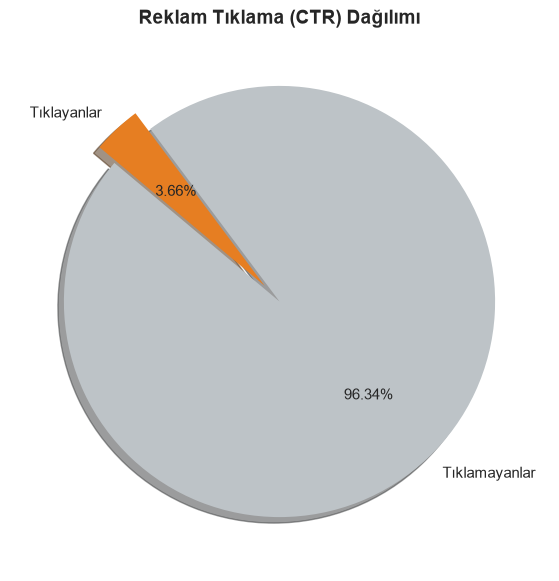

In [8]:
ctr_p = 0.04
visitors = 10000

# Ziyaretçi tıklama simülasyonu
clicks = np.random.binomial(n=1, p=ctr_p, size=visitors)
total_clicks = np.sum(clicks)
observed_ctr = np.mean(clicks)

print(f"🎯 Toplam Ziyaretçi: {visitors:,}")
print(f"🖱️ Toplam Tıklama Sayısı: {total_clicks}")
print(f"📊 Gözlemlenen Tıklama Oranı (CTR): %{observed_ctr * 100:.2f}")
print(f"🎯 Beklenen Tıklama Oranı (CTR): %{ctr_p * 100:.2f}")

# Pasta grafiği ile görselleştirme
plt.figure(figsize=(7, 7))
plt.pie([visitors - total_clicks, total_clicks], 
        labels=['Tıklamayanlar', 'Tıklayanlar'], 
        autopct='%1.2f%%', 
        startangle=140, 
        colors=['#bdc3c7', '#e67e22'], 
        explode=(0, 0.1), 
        shadow=True)
plt.title('Reklam Tıklama (CTR) Dağılımı', fontsize=14, fontweight='bold')
plt.show()

### 🏭 Senaryo 2: Fabrika Kalite Kontrol ve Hata Tespiti
Bir üretim bandında üretilen her parçanın hatalı çıkma olasılığı $p = 0.015$ (%1.5)'tir.
Günlük $5,000$ adet parça üretilmektedir.

In [9]:
defect_p = 0.015
daily_production = 5000

production_batch = np.random.binomial(n=1, p=defect_p, size=daily_production)
defective_count = np.sum(production_batch)
defect_rate = np.mean(production_batch)

print(f"🏭 Günlük Üretim: {daily_production:,} adet")
print(f"⚠️ Hatalı Ürün Sayısı: {defective_count} adet")
print(f"📈 Hata Oranı: %{defect_rate * 100:.2f} (Hedef: %{defect_p * 100:.2f})")

🏭 Günlük Üretim: 5,000 adet
⚠️ Hatalı Ürün Sayısı: 69 adet
📈 Hata Oranı: %1.38 (Hedef: %1.50)


---
## 🔗 9. Bernoulli Dağılımı ile Diğer Dağılımların İlişkisi

Bernoulli dağılımı, istatistikteki birçok karmaşık dağılımın yapı taşıdır:

```
              +---------------------------------------------------+
              |          BERNOULLI DAĞILIMI: X ~ Bern(p)          |
              +---------------------------------------------------+
                                       |
          +----------------------------+----------------------------+
          |                            |                            |
          v                            v                            v
  [n Kez Bağımsız Tekrar]    [İlk Başarıya Kadar Deneme]    [r. Başarıya Kadar Deneme]
          |                            |                            |
          v                            v                            v
   BİNOM DAĞILIMI                 GEOMETRİK                  NEGATİF BİNOM
    Binomial(n, p)               Geometric(p)                NegBinomial(r, p)
```

1. **Binom Dağılımı (Binomial Distribution):** Bağımsız ve özdeş (i.i.d.) $n$ adet Bernoulli rastgele değişkeninin toplamı bir Binom Dağılımı oluşturur: $Y = \sum_{i=1}^n X_i \sim \text{Binomial}(n, p)$.
2. **Geometrik Dağılım (Geometric Distribution):** Bernoulli denemelerinde **ilk başarıyı elde edene kadar** yapılan başarısız deneme sayısını modeler.
3. **Negatif Binom Dağılımı (Negative Binomial Distribution):** Bernoulli denemelerinde **$r$. başarıyı elde edene kadar** yapılan deneme sayısını modeler.
4. **Kategorik Dağılım (Categorical / Multinoulli Distribution):** Bernoulli dağılımının $2$'den fazla olası sonuca sahip durumlara (örn: 6 yüzlü zar atışı) genelleştirilmiş halidir.

---
## 📝 10. Özet ve Hızlı Başvuru Kartı

| Kavram | Açıklama / Formül |
| :--- | :--- |
| **Dağılım Türü** | Ayrık (Discrete) |
| **Olay Uzayı** | $k \in \{0, 1\}$ |
| **Parametre** | $p \in [0, 1]$ (Başarı olasılığı) |
| **PMF** | $P(X = k) = p^k (1 - p)^{1 - k}$ |
| **Beklenen Değer** | $E[X] = p$ |
| **Varyans** | $\text{Var}(X) = p(1 - p)$ |
| **Python SciPy** | `scipy.stats.bernoulli(p)` |
| **Python NumPy** | `np.random.binomial(n=1, p=p, size=N)` |

---